**EDA Stock Data**

Author: Jesús Enrique Miranda Blanco

In [1]:
import pandas as pd
import numpy as np
from datetime import date, timedelta

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# import pandas_datareader.data as web
import yfinance as yf


pd.set_option("display.max_columns",80)

In [2]:
yesterday = str(date.today() - timedelta(days = 1))
print("Today's date:", yesterday)

Today's date: 2023-02-06


In [11]:
%%time
start_date = "2019-01-01"
tickers = ['MAT','DIS','KO', 'NVDA','PFE','MRNA', "AAPL", "META", "TSLA", "^GSPC","MSFT", "NU"]
print(f"The number of stock to download are {len(tickers)}")
all_data = yf.download(tickers, start_date, yesterday)
all_data.info()

The number of stock to download are 12
[*********************100%***********************]  12 of 12 completed
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1031 entries, 2019-01-02 00:00:00-05:00 to 2023-02-03 00:00:00-05:00
Data columns (total 72 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Adj Close, AAPL)   1031 non-null   float64
 1   (Adj Close, DIS)    1031 non-null   float64
 2   (Adj Close, KO)     1031 non-null   float64
 3   (Adj Close, MAT)    1031 non-null   float64
 4   (Adj Close, META)   1031 non-null   float64
 5   (Adj Close, MRNA)   1031 non-null   float64
 6   (Adj Close, MSFT)   1031 non-null   float64
 7   (Adj Close, NU)     290 non-null    float64
 8   (Adj Close, NVDA)   1031 non-null   float64
 9   (Adj Close, PFE)    1031 non-null   float64
 10  (Adj Close, TSLA)   1031 non-null   float64
 11  (Adj Close, ^GSPC)  1031 non-null   float64
 12  (Close, AAPL)       1031 non-null   float64


# Missing review

In [12]:
df_missings_agg = all_data.isna().sum().sort_values()
df_missings_agg[
    df_missings_agg > 0
]

Low        NU    741
Adj Close  NU    741
Open       NU    741
Volume     NU    741
Close      NU    741
High       NU    741
dtype: int64

In [13]:
adj_close_data = all_data["Adj Close"].copy()
adj_close_data.head()

,AAPL,DIS,KO,MAT,META,MRNA,MSFT,NU,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,,,
2019-01-02 00:00:00-05:00,38.105137,107.654343,41.413998,9.76,135.679993,15.330000,96.874695,NaN,33.805473,35.108089,20.674667,2510.030029
2019-01-03 00:00:00-05:00,34.309586,105.046211,41.158077,9.27,131.740005,15.500000,93.310867,NaN,31.763046,34.125866,20.024000,2447.889893
2019-01-04 00:00:00-05:00,35.774239,108.286606,41.978756,10.41,137.949997,16.959999,97.650688,NaN,33.798031,34.905151,21.179333,2531.939941
2019-01-07 00:00:00-05:00,35.694611,109.225136,41.431641,11.21,138.050003,16.270000,97.775238,NaN,35.587326,35.091858,22.330667,2549.689941
2019-01-08 00:00:00-05:00,36.375061,110.074753,41.899345,11.74,142.529999,16.950001,98.484169,NaN,34.701363,35.254200,22.356667,2574.409912


In [17]:
adj_close_data[
    adj_close_data.NU.notna()
].isna().sum()#.index.min()

AAPL     0
DIS      0
KO       0
MAT      0
META     0
MRNA     0
MSFT     0
NU       0
NVDA     0
PFE      0
TSLA     0
^GSPC    0
dtype: int64

In [18]:
adj_close_data[
    adj_close_data.NU.notna()
].index.min()

Timestamp('2021-12-09 00:00:00-0500', tz='America/New_York')

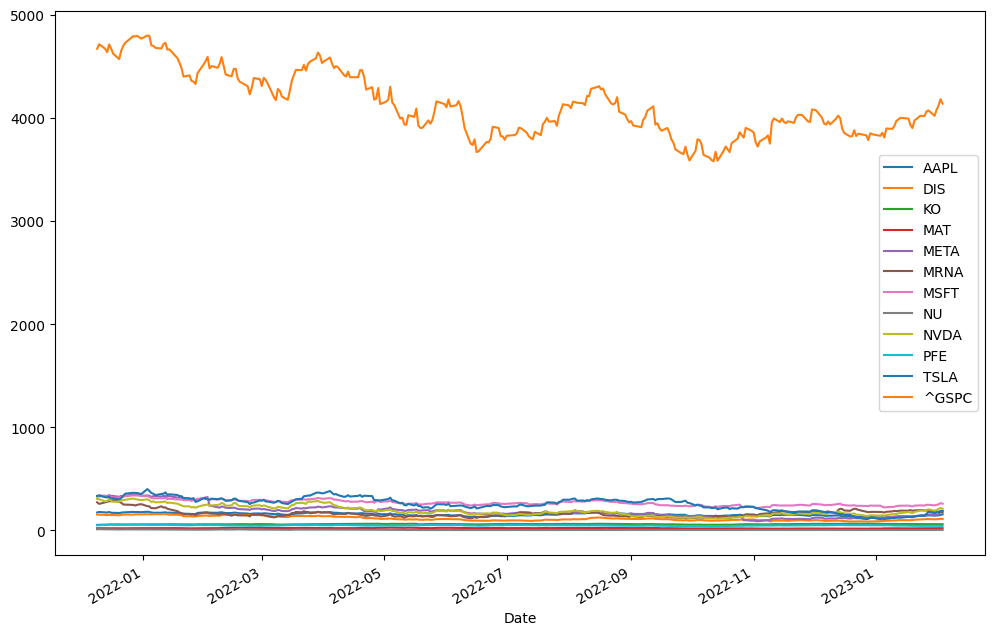

In [23]:
adj_close_data[
    adj_close_data.NU.notna()
].plot(
    figsize=(12,8)
);

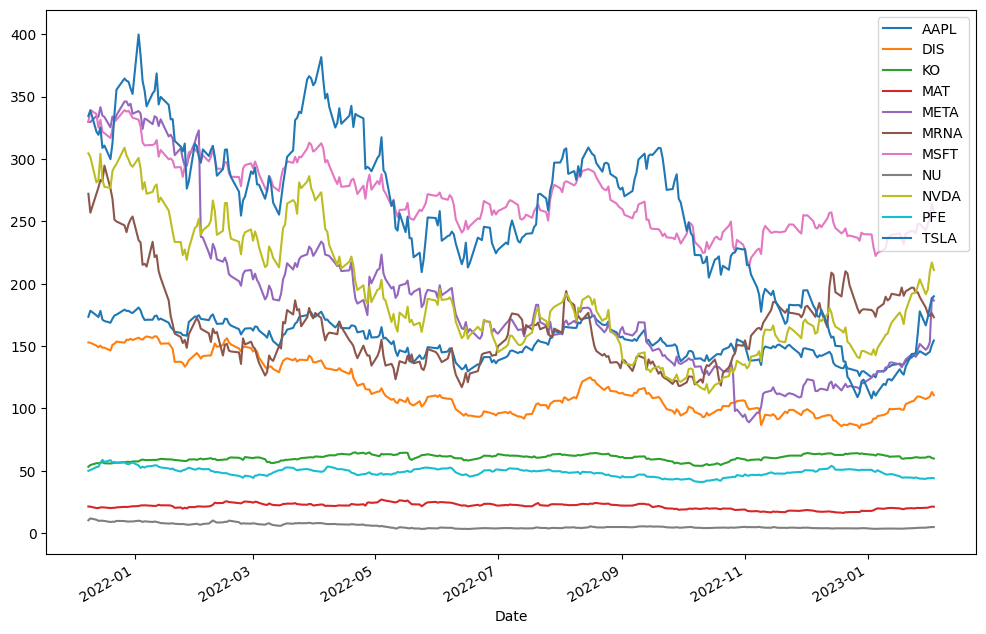

In [27]:
adj_close_data[
    adj_close_data.NU.notna()
].drop(
    columns=["^GSPC"]
).plot(
    figsize=(12,8)
);

In [28]:
adj_close_data = adj_close_data.drop(columns='NU')
adj_close_data.head()

,AAPL,DIS,KO,MAT,META,MRNA,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,,
2019-01-02 00:00:00-05:00,38.105137,107.654343,41.413998,9.76,135.679993,15.330000,96.874695,33.805473,35.108089,20.674667,2510.030029
2019-01-03 00:00:00-05:00,34.309586,105.046211,41.158077,9.27,131.740005,15.500000,93.310867,31.763046,34.125866,20.024000,2447.889893
2019-01-04 00:00:00-05:00,35.774239,108.286606,41.978756,10.41,137.949997,16.959999,97.650688,33.798031,34.905151,21.179333,2531.939941
2019-01-07 00:00:00-05:00,35.694611,109.225136,41.431641,11.21,138.050003,16.270000,97.775238,35.587326,35.091858,22.330667,2549.689941
2019-01-08 00:00:00-05:00,36.375061,110.074753,41.899345,11.74,142.529999,16.950001,98.484169,34.701363,35.254200,22.356667,2574.409912


In [31]:
(34.309586 - 38.105137) / 38.105137

-0.09960733115852585

In [32]:
(35.774239- 34.309586) / 34.309586

0.042689323036424816

In [30]:
yield_data = adj_close_data.pct_change().dropna()
yield_data.head()

,AAPL,DIS,KO,MAT,META,MRNA,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,,
2019-01-03 00:00:00-05:00,-0.099607,-0.024227,-0.006180,-0.050205,-0.029039,0.011089,-0.036788,-0.060417,-0.027977,-0.031472,-0.024757
2019-01-04 00:00:00-05:00,0.042689,0.030847,0.019940,0.122977,0.047138,0.094193,0.046509,0.064068,0.022836,0.057697,0.034336
2019-01-07 00:00:00-05:00,-0.002226,0.008667,-0.013033,0.076849,0.000725,-0.040684,0.001275,0.052941,0.005349,0.054361,0.007010
2019-01-08 00:00:00-05:00,0.019063,0.007779,0.011289,0.047279,0.032452,0.041795,0.007251,-0.024895,0.004626,0.001164,0.009695
2019-01-09 00:00:00-05:00,0.016982,0.011219,-0.019166,-0.009370,0.011927,-0.036578,0.014300,0.019667,-0.002072,0.009483,0.004098


In [24]:
help(pd.DataFrame.pct_change)

Help on function pct_change in module pandas.core.generic:

pct_change(self: 'NDFrameT', periods=1, fill_method='pad', limit=None, freq=None, **kwargs) -> 'NDFrameT'
    Percentage change between the current and a prior element.
    
    Computes the percentage change from the immediately previous row by
    default. This is useful in comparing the percentage of change in a time
    series of elements.
    
    Parameters
    ----------
    periods : int, default 1
        Periods to shift for forming percent change.
    fill_method : str, default 'pad'
        How to handle NAs **before** computing percent changes.
    limit : int, default None
        The number of consecutive NAs to fill before stopping.
    freq : DateOffset, timedelta, or str, optional
        Increment to use from time series API (e.g. 'M' or BDay()).
    **kwargs
        Additional keyword arguments are passed into
        `DataFrame.shift` or `Series.shift`.
    
    Returns
    -------
    chg : Series or Data